#EDA & preprocessing


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

file_path = "/content/drive/MyDrive/Ironhack NLP Project/archive/1429_1.csv"

df = pd.read_csv(file_path)

/tmp/ipykernel_19362/3389370815.py:5: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
df.shape

(34660, 21)

In [4]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [5]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')

In [6]:
df.isna().sum()

,0
id,0
name,6760
asins,2
brand,0
categories,0
keys,0
manufacturer,0
reviews.date,39
reviews.dateAdded,10621
reviews.dateSeen,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["reviews.text"].duplicated().sum()

np.int64(0)

In [9]:
df["reviews.rating"].value_counts()

,count
reviews.rating,
5.0,23775
4.0,8541
3.0,1499
1.0,410
2.0,402


In [10]:
 df = df.dropna(subset = ['reviews.text', 'reviews.rating'])

In [11]:
def sentiment(rating):
      if rating <= 2:
          return 'negative'
      elif rating == 3:
          return 'neutral'
      else:
          return 'positive'

In [12]:
df['sentiment'] = df['reviews.rating'].apply(sentiment)

In [13]:
df['sentiment'].value_counts()

,count
sentiment,
positive,32315
neutral,1499
negative,812


In [14]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sentiment
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter,positive
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman,positive
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ,positive
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks,positive
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42,positive


In [15]:
import matplotlib.pyplot as plt

<Axes: xlabel='sentiment'>

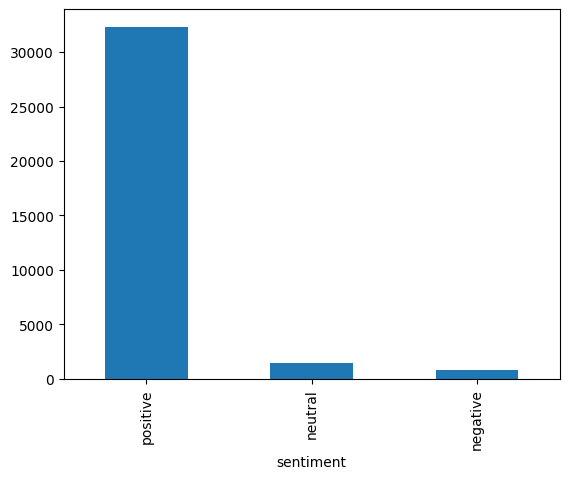

In [16]:
df['sentiment'].value_counts().plot(kind = 'bar')

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
tfidf = TfidfVectorizer(max_features = 7500)

In [19]:
from sklearn.model_selection import train_test_split



In [20]:
X = df['reviews.text']
y = df['sentiment']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify = y, test_size = 0.2, random_state = 42)

In [22]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [23]:
X_test_tfidf = tfidf.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model = LogisticRegression(class_weight = 'balanced', max_iter = 1000)

In [26]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [27]:
y_pred = model.predict(X_test_tfidf)

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(y_test, y_pred)

0.8251516026566561

In [30]:
from sklearn.metrics import classification_report

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.25      0.58      0.35       162
     neutral       0.15      0.46      0.22       300
    positive       0.98      0.85      0.91      6464

    accuracy                           0.83      6926
   macro avg       0.46      0.63      0.49      6926
weighted avg       0.93      0.83      0.87      6926



In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [33]:
cm = confusion_matrix(y_test, y_pred)

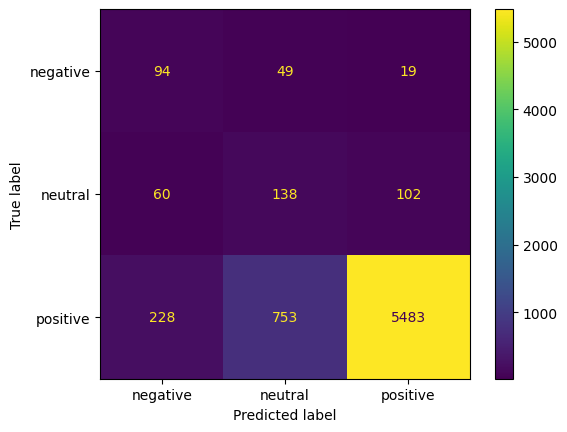

In [34]:
ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['negative', 'neutral', 'positive']).plot()

In [35]:
cm_norm = confusion_matrix(y_test, y_pred, normalize = 'true')

Text(0.5, 1.0, 'Normalized Confusion Matrix - Logistic Regression')

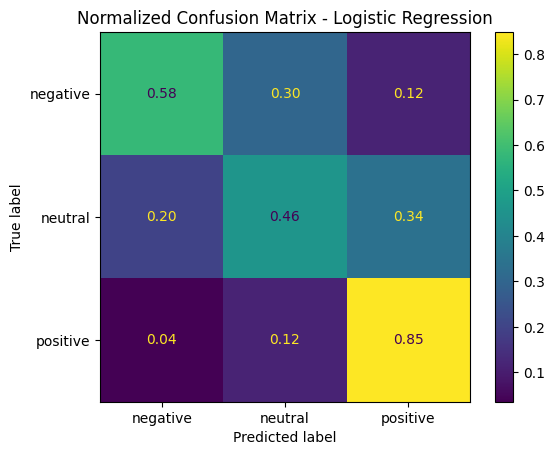

In [36]:
ConfusionMatrixDisplay(confusion_matrix = cm_norm, display_labels = ['negative', 'neutral', 'positive']).plot(values_format='.2f')
plt.title('Normalized Confusion Matrix - Logistic Regression')

In [37]:
from sklearn.naive_bayes import MultinomialNB

In [38]:
nb_model = MultinomialNB()

In [39]:
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [40]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [41]:
accuracy_score(y_test, y_pred_nb)

0.9330060641062663

In [42]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       162
     neutral       0.00      0.00      0.00       300
    positive       0.93      1.00      0.97      6464

    accuracy                           0.93      6926
   macro avg       0.31      0.33      0.32      6926
weighted avg       0.87      0.93      0.90      6926



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
from sklearn.svm import LinearSVC

In [44]:
svc_model = LinearSVC(class_weight = 'balanced')

In [45]:
svc_model.fit(X_train_tfidf, y_train)

LinearSVC(class_weight='balanced')

In [46]:
y_pred_svc = svc_model.predict(X_test_tfidf)

In [47]:
accuracy_score(y_test, y_pred_svc)

0.9075945711810569

In [48]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

    negative       0.34      0.35      0.34       162
     neutral       0.21      0.25      0.23       300
    positive       0.96      0.95      0.96      6464

    accuracy                           0.91      6926
   macro avg       0.50      0.52      0.51      6926
weighted avg       0.91      0.91      0.91      6926



In [49]:
cm_norm = confusion_matrix(y_test, y_pred_svc, normalize = 'true')

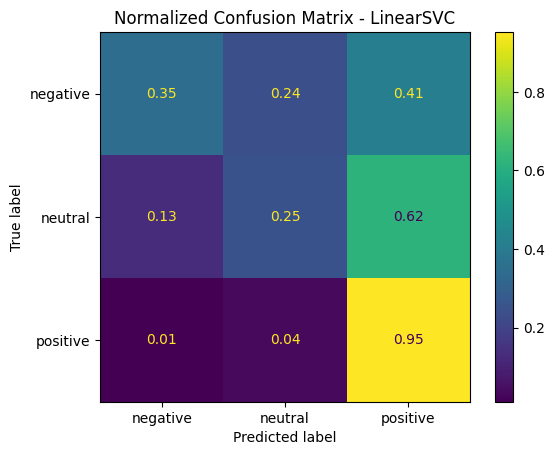

In [50]:
ConfusionMatrixDisplay(confusion_matrix = cm_norm, display_labels = ['negative', 'neutral', 'positive']).plot(values_format='.2f')
plt.title('Normalized Confusion Matrix - LinearSVC')
plt.savefig("linear_svc_confusion_matrix.png", bbox_inches="tight", dpi=300)

In [51]:
# the dataset was very imbalanced and had most of positive reviews, I compared 3 models: Logistic Regression, Naive Bayes and LinearSVC, and found out that Naive Bayes is completely unsuitable as it gave a good accuracy but f1 score was 0.0 for negative and neutral. Even though LinearSvc had not the best accuracy out of those 3 models it had the best f1 score so i decided to pick that one. This shows that accuracy alone can be misleading when the dataset is highly imbalanced.

In [52]:
#              precision    recall  f1-score   support

#    negative       0.34      0.35      0.34       162
#     neutral       0.21      0.25      0.23       300
#   positive       0.96      0.95      0.96      6464

#    accuracy                           0.91      6926
#  macro avg       0.50      0.52      0.51      6926
#weighted avg       0.91      0.91      0.91      6926



# Product Category Clustering

In [53]:
df['categories'].value_counts()

,count
categories,
"Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, Tech Toys, Movies, Music,Electronics,iPad & Tablets,Android Tablets,Frys",10966
"Stereos,Remote Controls,Amazon Echo,Audio Docks & Mini Speakers,Amazon Echo Accessories,Kitchen & Dining Features,Speaker Systems,Electronics,TVs Entertainment,Clearance,Smart Hubs & Wireless Routers,Featured Brands,Wireless Speakers,Smart Home & Connected Living,Home Security,Kindle Store,Home Automation,Home, Garage & Office,Home,Voice-Enabled Smart Assistants,Virtual Assistant Speakers,Portable Audio & Headphones,Electronics Features,Amazon Device Accessories,iPod, Audio Player Accessories,Home & Furniture Clearance,Consumer Electronics,Smart Home,Surveillance,Home Improvement,Smart Home & Home Automation Devices,Smart Hubs,Home Safety & Security,Voice Assistants,Alarms & Sensors,Amazon Devices,Audio,Holiday Shop",6619
"Back To College,College Electronics,College Tvs & Home Theater,Electronics,Tvs & Home Theater,Streaming Devices,Featured Brands,Amazon Devices,Holiday Shop,Ways To Shop,TV & Home Theater,Streaming Media Players,All Streaming Media Players,TVs Entertainment,Video Games,Kindle Store,Electronics Features,Kids & Family,Fire TV",5056
"Walmart for Business,Office Electronics,Tablets,Office,Electronics,iPad & Tablets,Windows Tablets,All Windows Tablets,Computers & Tablets,E-Readers & Accessories,E-Readers,eBook Readers,Kindle E-readers,Computers/Tablets & Networking,Tablets & eBook Readers,Electronics Features,Books & Magazines,Book Accessories,eReaders,TVs & Electronics,Computers & Laptops,Tablets & eReaders",3176
"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",2814
"Tablets,Fire Tablets,Computers & Tablets,All Tablets",1699
"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",1038
"Featured Brands,Electronics,Amazon Devices,Home,Home Improvement,Home Safety & Security,Home Security,Alarms & Sensors,Smart Home & Home Automation Devices,Mobile,Mobile Speakers,Mobile Bluetooth Speakers,Smart Hubs & Wireless Routers,Smart Hubs,Home, Garage & Office,Smart Home,Voice Assistants,Smart Home & Connected Living,Amazon Tap,Portable Audio,MP3 Accessories,Speakers,Amazon Echo,Electronics Features,TVs & Electronics,Portable Audio & Electronics,MP3 Player Accessories,Home Theater & Audio,Kindle Store,Frys,Electronic Components,Home Automation,Electronics, Tech Toys, Movies, Music,Audio,Bluetooth Speakers",636
"Walmart for Business,Office Electronics,Tablets,Electronics,iPad & Tablets,All Tablets,Computers & Tablets,E-Readers & Accessories,Kindle E-readers,Electronics Features,eBook Readers,See more Amazon Kindle Voyage (Wi-Fi),See more Amazon Kindle Voyage 4GB, Wi-Fi 3G (Unlocked...",580


In [54]:
df['name'].value_counts()

,count
name,
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",10962
"Echo (White),,,\r\nEcho (White),,,",3309
"Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,",3176
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",2814
"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",2527
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",1685
"Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,",1033
"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers,",580
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",368


In [55]:
df['name'] = df['name'].fillna('')
df['categories'] = df['categories'].fillna('')

In [56]:
df ['cluster_text'] = df['categories'] + ' ' + df['name'] + ' ' + df['reviews.text']

In [57]:
df['cluster_text'].head()

,cluster_text
0,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
1,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
2,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
3,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
4,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."


In [58]:
cluster_tfidf = TfidfVectorizer(max_features = 7500)

In [59]:
X_cluster_tfidf = cluster_tfidf.fit_transform(df['cluster_text'])

In [60]:
from sklearn.cluster import KMeans

In [61]:
kmeans_model = KMeans(n_clusters = 5, random_state = 42).fit(X_cluster_tfidf)

In [62]:
df['cluster'] = kmeans_model.labels_

In [63]:
df['cluster'].value_counts()

,count
cluster,
0,11037
2,8288
1,7255
3,5052
4,2994


In [64]:
df[df['cluster'] == 0][['categories', 'name', 'reviews.text', 'cluster']].head(10)

,categories,name,reviews.text,cluster
3695,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Good basic tablet for checking email , web bro...",0
3696,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",I love this tablet. It was a great buy. I woul...,0
3697,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Brought my old tablet in to my local store, an...",0
3698,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Good Inexpensive tablet for someone that does ...,0
3699,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",I got this for my niece. I would say this prod...,0
3700,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",A great product for my kids and great learning...,0
3701,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Purchased for my toddler. Best investment yet....,0
3702,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Buying this device I thought it could replace ...,0
3703,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",This is a great tablet for us seniors because ...,0
3704,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Nice tablet for the price. Got it for my son B...,0


In [65]:
df[df['cluster'] == 1][['categories', 'name', 'reviews.text', 'cluster']].head(10)

,categories,name,reviews.text,cluster
21952,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",I really enjoy the Echo. I got an Echo Dot and...,1
21953,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",I like it. I use mostly for music.,1
21954,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",Great for music! Speaker quality is excellent!...,1
21955,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",Love to use for news and weather Has been help...,1
21956,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",Really is just as good as the commercials make...,1
21957,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",It's Great! I like being able to add things to...,1
21958,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",The Echo is the coolest thing! I love it. I ev...,1
21959,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",This was a birthday gift for my son-in-law and...,1
21960,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",I love asking Alexa questions and getting the ...,1
21961,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,","this was purchased for a friend, and his famil...",1


In [66]:
df[df['cluster'] == 2][['categories', 'name', 'reviews.text', 'cluster']].head(10)

,categories,name,reviews.text,cluster
2814,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,Very lightweight and portable with excellent b...,2
2815,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,I like this so much more than the Voyage. The ...,2
2816,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,Replacing older reader without a light and tra...,2
2817,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,This is my first e-reader. I didn't know about...,2
2818,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,This kindle is awesome. I love the design of i...,2
2819,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,The new Kindle is a great gift and fantastic e...,2
2820,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,Met all my expectations! Lightweight and compa...,2
2821,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,I thought long and hard about upgrading from m...,2
2822,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,I own a Kindle HDX 8.9 and wanted something sm...,2
2823,"eBook Readers,Kindle E-readers,Computers & Tab...",Kindle Oasis E-reader with Leather Charging Co...,Got me reading again! Love the merlot cover. T...,2


In [67]:
df[df['cluster'] == 3][['categories', 'name', 'reviews.text', 'cluster']].head(10)

,categories,name,reviews.text,cluster
29573,"Back To College,College Electronics,College Tv...",,The Amazon Fire TV works better and faster tha...,3
29574,"Back To College,College Electronics,College Tv...",,I like the product and would tell others about...,3
29575,"Back To College,College Electronics,College Tv...",,"Really like the voice commands, including comm...",3
29576,"Back To College,College Electronics,College Tv...",,Got it so I can have everything in one device ...,3
29577,"Back To College,College Electronics,College Tv...",,Like the voice command option to search for sh...,3
29578,"Back To College,College Electronics,College Tv...",,"Decent, but have to reset monthly, i have to u...",3
29579,"Back To College,College Electronics,College Tv...",,Great purchase and good investment.Also wonder...,3
29580,"Back To College,College Electronics,College Tv...",,Follow the instruction on youtube and you can ...,3
29581,"Back To College,College Electronics,College Tv...",,"Works as described, happy with the purchase.go...",3
29582,"Back To College,College Electronics,College Tv...",,Works exactly as I hoped and have had no issue...,3


In [68]:
df[df['cluster'] == 4][['categories', 'name', 'reviews.text', 'cluster']].head(10)

,categories,name,reviews.text,cluster
0,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",This product so far has not disappointed. My c...,4
1,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",great for beginner or experienced person. Boug...,4
2,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Inexpensive tablet for him to use and learn on...,4
3,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",I've had my Fire HD 8 two weeks now and I love...,4
4,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",I bought this for my grand daughter when she c...,4
5,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",This amazon fire 8 inch tablet is the perfect ...,4
6,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Great for e-reading on the go, nice and light ...",4
7,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","I gave this as a Christmas gift to my inlaws, ...",4
8,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Great as a device to read books. I like that i...,4
9,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",I love ordering books and reading them with th...,4


In [69]:
df[df['cluster'] == 0][['categories', 'name', 'reviews.text', 'cluster']].sample(10, random_state=42)

,categories,name,reviews.text,cluster
5209,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Bought this as a Xmas gift for my 5 yr old gra...,0
7474,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",I know I can pay to get rid of the ads but it'...,0
6025,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",A nice high quality tablet with a fast process...,0
13083,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",My kids love this tablet and I love the price ...,0
6868,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",My 6 year old loves it easy to use has lots of...,0
7500,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",This is very easy to use and lightweight. Very...,0
11233,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",I cant ask for more for this price! very pleas...,0
7077,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",My elderly mother really enjoys this tablet. E...,0
11137,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",I bought this tablet for my son for Christmas....,0
9847,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",I purchased this tablet for my grandma and she...,0


In [70]:
df[df['cluster'] == 1][['categories', 'name', 'reviews.text', 'cluster']].sample(10, random_state=42)

,categories,name,reviews.text,cluster
24909,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Specia...","i adore my echo...i wake up in morning, get a ...",1
23647,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,","Bought the Echo for my hubby's birthday, and i...",1
25889,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",I love using Alexa. She will play music when a...,1
28301,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",,Very handy gadget to have at home. Use frequen...,1
29054,"Featured Brands,Electronics,Amazon Devices,Hom...",,I have an Alexa but wanted a speaker for trave...,1
24618,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",Great addition to the family room. Easy to set...,1
23603,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",This is one of the best products that someone ...,1
27558,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,","For me, it is only great for playing english-l...",1
25414,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",Just as advertised. Bought two units for diffe...,1
26123,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",I like the tech but it goes off off line way t...,1


In [71]:
df[df['cluster'] == 2][['categories', 'name', 'reviews.text', 'cluster']].sample(10, random_state=42)

,categories,name,reviews.text,cluster
28636,"Chargers & Adapters,Computers & Accessories,Ta...",,I connected my Fire HD and another tablet to t...,2
3346,"Amazon Devices & Accessories,Amazon Device Acc...","All-New Kindle E-reader - Black, 6 Glare-Free ...",It does what it is supposed to do.,2
15699,"Computers/Tablets & Networking,Tablets & eBook...","Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...","Quite light, easy to conceal, easy to use and ...",2
18235,"Walmart for Business,Office Electronics,Tablet...",Amazon Kindle Paperwhite - eBook reader - 4 GB...,"Great size, easy to read at night and no glare...",2
16911,"Tablets,Fire Tablets,Computers & Tablets,All T...","Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",Easy for a 5 year old to learn.. the apps on t...,2
15268,"Computers/Tablets & Networking,Tablets & eBook...",Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,I am a senior citizen who is not that great on...,2
3226,"Amazon Devices & Accessories,Amazon Device Acc...",Amazon 5W USB Official OEM Charger and Power A...,very overpriced!,2
21011,"Walmart for Business,Office Electronics,Tablet...","Kindle Paperwhite E-reader - White, 6 High-Res...",I exchanged the paper white that I had bought ...,2
21558,"Fire Tablets,Tablets,Computers & Tablets,All T...","Echo (White),,,\r\nEcho (White),,,",Purchased this Kindle Fire HD8 from Best Buy. ...,2
17499,"Walmart for Business,Office Electronics,Tablet...",Amazon Kindle Paperwhite - eBook reader - 4 GB...,It's great deal for a person who's working at ...,2


In [72]:
df[df['cluster'] == 3][['categories', 'name', 'reviews.text', 'cluster']].sample(10, random_state=42)

,categories,name,reviews.text,cluster
34286,"Back To College,College Electronics,College Tv...",,It is very easy to set up and easy to use. I l...,3
30264,"Back To College,College Electronics,College Tv...",,I bought both the Amazon tv & the fire stick. ...,3
29638,"Back To College,College Electronics,College Tv...",,I recently dropped my cable provider and i had...,3
31925,"Back To College,College Electronics,College Tv...",,"Great product, it streams fast and is a good r...",3
34258,"Back To College,College Electronics,College Tv...",,Set up was easy and load times and picture qua...,3
29966,"Back To College,College Electronics,College Tv...",,I had a firestick but broke it so I upgraded t...,3
30997,"Back To College,College Electronics,College Tv...",,Love that Prime membership allows me to see al...,3
30215,"Back To College,College Electronics,College Tv...",,Great device for all your media needs. Plugs r...,3
32410,"Back To College,College Electronics,College Tv...",,This is one of the best on the market great to...,3
31311,"Back To College,College Electronics,College Tv...",,In an effort to cut the cord we purchased the ...,3


In [73]:
df[df['cluster'] == 4][['categories', 'name', 'reviews.text', 'cluster']].sample(10, random_state=42)

,categories,name,reviews.text,cluster
2366,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",I am familiarizing my self with no conclusion ...,4
1088,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Tablet is a great tool to use the world wide w...,4
321,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",I bought two of these Amazon Fire HD tablets i...,4
1037,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Bought this for my niece and she loves it. Ver...,4
1503,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","I started with the 7"" little brother and liked...",4
178,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",great device for the price. good looking scree...,4
495,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","A great Kindle reader. Easy to order, read and...",4
471,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",The Fire HD8 strikes an excellent balance betw...,4
2534,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Very good price good item. Would purchase agai...,4
289,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",I found it to be very versatile and enjoyable ...,4


In [74]:
words = cluster_tfidf.get_feature_names_out()

for i in range(5):
    top_words = kmeans_model.cluster_centers_[i].argsort()[-10:][::-1]
    print(i, words[top_words])

0 ['tablets' 'fire' 'tablet' 'electronics' 'android' 'toys' 'frys' 'movies'
 'tech' 'music']
1 ['home' 'smart' 'audio' 'speakers' 'amazon' 'echo' 'accessories'
 'automation' 'hubs' 'security']
2 ['tablets' 'readers' 'ebook' 'computers' 'paperwhite' 'kindle' 'ereaders'
 'windows' 'accessories' 'electronics']
3 ['streaming' 'college' 'theater' 'tv' 'home' 'media' 'players' 'tvs' 'to'
 'shop']
4 ['tablets' 'hd' 'new' 'fire' '16' 'all' 'tablet' 'magenta' 'special'
 'offers']


In [75]:
cluster_names = {
    0: 'Fire tablets',
    1: 'Echo/SmartHome',
    2: 'Kindle/E-readers',
    3: 'Fire TV/Streaming devices',
    4: 'Fire HD 8 tablets'
}

In [76]:
df["cluster_name"] = df["cluster"].map(cluster_names)

In [77]:
df[["cluster", "cluster_name"]].sample(10, random_state = 42)

,cluster,cluster_name
21267,2,Kindle/E-readers
21797,2,Kindle/E-readers
20228,2,Kindle/E-readers
27304,1,Echo/SmartHome
30059,3,Fire TV/Streaming devices
2857,2,Kindle/E-readers
1188,4,Fire HD 8 tablets
9904,0,Fire tablets
32884,3,Fire TV/Streaming devices
9952,0,Fire tablets


<Axes: xlabel='cluster_name'>

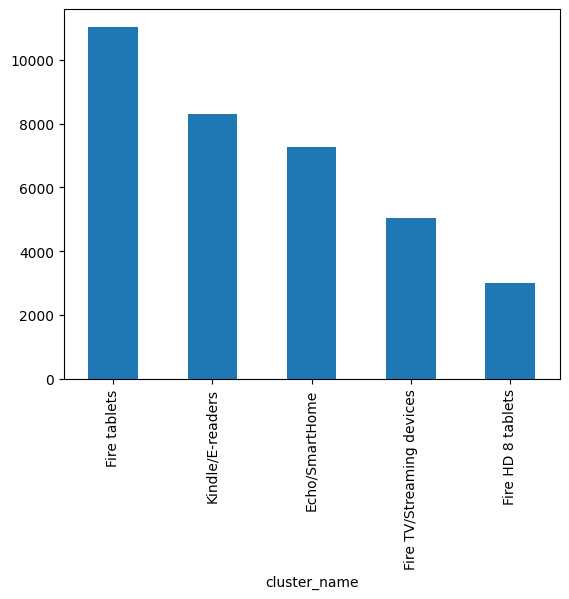

In [78]:
df['cluster_name'].value_counts().plot(kind = 'bar')

In [79]:
# I used Tf-Idf and KMeans with 5 clusters (as said in the project description) and then I validated clusters by checking top TfIdf words and random samples. The resulting groups are on the graph. I will be using those clusters for exercise 3


# Review Summarizing

In [80]:
fire_tablets_sample = df[df['cluster_name'] == 'Fire tablets'].sample(20, random_state = 42)
fire_tablets_sample['reviews.text']


,reviews.text
5209,Bought this as a Xmas gift for my 5 yr old gra...
7474,I know I can pay to get rid of the ads but it'...
6025,A nice high quality tablet with a fast process...
13083,My kids love this tablet and I love the price ...
6868,My 6 year old loves it easy to use has lots of...
7500,This is very easy to use and lightweight. Very...
11233,I cant ask for more for this price! very pleas...
7077,My elderly mother really enjoys this tablet. E...
11137,I bought this tablet for my son for Christmas....
9847,I purchased this tablet for my grandma and she...


In [81]:
fire_tablets_sample['reviews.text']

,reviews.text
5209,Bought this as a Xmas gift for my 5 yr old gra...
7474,I know I can pay to get rid of the ads but it'...
6025,A nice high quality tablet with a fast process...
13083,My kids love this tablet and I love the price ...
6868,My 6 year old loves it easy to use has lots of...
7500,This is very easy to use and lightweight. Very...
11233,I cant ask for more for this price! very pleas...
7077,My elderly mother really enjoys this tablet. E...
11137,I bought this tablet for my son for Christmas....
9847,I purchased this tablet for my grandma and she...


In [82]:
fire_tablets_text =' '.join(fire_tablets_sample['reviews.text'])
print(fire_tablets_text)

Bought this as a Xmas gift for my 5 yr old grandson. He really loves it. I think the charger could use a longer cord though. He plays PBS Kids games and it really burns the battery down quick. I know I can pay to get rid of the ads but it's just a bad idea, tablet works fine otherwise. And if your okay with Amazon apps. A nice high quality tablet with a fast processor. Superb image quality, long battery life, and a great value. Equal quality and performance of an IPad at a fraction of the cost. My kids love this tablet and I love the price so it's a win win situation My 6 year old loves it easy to use has lots of apps This is very easy to use and lightweight. Very convenient I cant ask for more for this price! very please with the Kindle Fire features My elderly mother really enjoys this tablet. Easy to use and lightweight. I bought this tablet for my son for Christmas. I chose this one because it was the most popular tablet sold. He hasn't parted with it yet. I purchased this tablet f

In [83]:
len(fire_tablets_text)

3031

In [84]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [85]:
tokenizer = AutoTokenizer.from_pretrained('sshleifer/distilbart-cnn-12-6')

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [86]:
import transformers
transformers.__version__

'4.57.6'

In [87]:
!pip uninstall -y transformers
!pip install -q "transformers<5"

Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6


In [88]:
import transformers
transformers.__version__

'4.57.6'

In [89]:
!pip uninstall -y transformers
!pip install -q "transformers==4.57.6"

Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6


In [90]:
from transformers import pipeline

In [91]:
summarizer = pipeline('summarization', 'sshleifer/distilbart-cnn-12-6')

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Device set to use cpu


In [92]:
summarizer

In [93]:
summarizer(fire_tablets_text)

[{'summary_text': " The Kindle Fire is a great value at a fraction of the cost of an IPad . It's easy to handle, and hasn't had any issues breaking down . The charger cable is a pain to plug into the tablet, and some of the tablet versions of apps like Neko Atsume aren't good compared to the phone versions ."}]

In [94]:
summarizer(fire_tablets_text, min_length = 30, max_length = 80)

[{'summary_text': " The Kindle Fire is a great value at a fraction of the cost of an IPad . It's easy to handle, and hasn't had any issues breaking down . The charger cable is a pain to plug into the tablet and some of the tablet versions of apps like Neko Atsume aren't good compared to the phone versions ."}]

In [95]:
kindle_ereaders_sample = df[df['cluster_name'] == 'Kindle/E-readers'].sample(20, random_state = 42)
kindle_ereaders_sample['reviews.text']


,reviews.text
28636,I connected my Fire HD and another tablet to t...
3346,It does what it is supposed to do.
15699,"Quite light, easy to conceal, easy to use and ..."
18235,"Great size, easy to read at night and no glare..."
16911,Easy for a 5 year old to learn.. the apps on t...
15268,I am a senior citizen who is not that great on...
3226,very overpriced!
21011,I exchanged the paper white that I had bought ...
21558,Purchased this Kindle Fire HD8 from Best Buy. ...
17499,It's great deal for a person who's working at ...


In [96]:
kindle_ereaders_text =' '.join(kindle_ereaders_sample['reviews.text'])
print(kindle_ereaders_text)

I connected my Fire HD and another tablet to this power fast adapter and got a low power connection message. I purchased 2 chargers and will be returning them. The fire tablet charging process took a very long time. I eventually unplugged it and connected to another charger. It does what it is supposed to do. Quite light, easy to conceal, easy to use and quite quick. Great size, easy to read at night and no glare screen. Easy for a 5 year old to learn.. the apps on the Tablet are very good. I am a senior citizen who is not that great on computers or tablets, therefore, I need a book to help me understand how to do things on the tablet. I could not believe that this tablet did not come with an instruction booklet. It's taking me some time but I am learning how to get around this thing. That's why I can only give this product 4 stars instead of 5. very overpriced! I exchanged the paper white that I had bought for this Voyage. This is thinner, lighter and just easier to hold than the pape

In [97]:
len(kindle_ereaders_text)

4229

In [98]:
summarizer(kindle_ereaders_text, min_length = 30, max_length = 80)

[{'summary_text': " The Kindle Fire HD8 is a great tablet for the money . The only thing I would like to see is a longer battery life . The Kindle doesn't tell you what battery you have left, it just shows you the bar in the battery symbol ."}]

In [99]:
echo_smarthome_sample = df[df['cluster_name'] == 'Echo/SmartHome'].sample(20, random_state = 42)
echo_smarthome_sample['reviews.text']


,reviews.text
24909,"i adore my echo...i wake up in morning, get a ..."
23647,"Bought the Echo for my hubby's birthday, and i..."
25889,I love using Alexa. She will play music when a...
28301,Very handy gadget to have at home. Use frequen...
29054,I have an Alexa but wanted a speaker for trave...
24618,Great addition to the family room. Easy to set...
23603,This is one of the best products that someone ...
27558,"For me, it is only great for playing english-l..."
25414,Just as advertised. Bought two units for diffe...
26123,I like the tech but it goes off off line way t...


In [100]:
echo_smarthome_text =' '.join(echo_smarthome_sample['reviews.text'])
print(echo_smarthome_text)
print(len(echo_smarthome_text))

i adore my echo...i wake up in morning, get a quick weather, sports scores...and here in florida, i get to listen to my favorite nyc sports radio stations...i use it to access my music...and i recently purchased a audio book for the wife, and i am waiting until i give her that audiobook for xmas; the i can ask alexa to read it to me ! ... i am sure alexa does so much more...(i even asked it to convert to metric for me when i was cooking last week)...i do not have any smart devices in my house, so i havent had the opportunity to have alexa do that for me...but it is so much fun to use...and now, instead if reaching for laptop to google something...i just ask alexa first Bought the Echo for my hubby's birthday, and it is everything I expected. It is so easy to set up, and we enjoy it so much. We use it to play music (such as a certain genre or artist or particular song). The sound quality is very good. My grandkids love to hear their songs too. We use it to make our shopping list, as it'

In [101]:
summarizer(echo_smarthome_text, min_length = 30, max_length = 80)

[{'summary_text': ' Alexa is awesome, works for what I want, next lights. She actually listens to me. She will play music when asked, plays games, answers questions and starts my day with a good morning . Easy to set up and use. Easy to listen to Spotify on. Great addition to the family room .'}]

In [102]:
fire_tv_streaming_sample = df[df['cluster_name'] == 'Fire TV/Streaming devices'].sample(20, random_state = 42)
fire_tv_streaming_sample['reviews.text']

,reviews.text
34286,It is very easy to set up and easy to use. I l...
30264,I bought both the Amazon tv & the fire stick. ...
29638,I recently dropped my cable provider and i had...
31925,"Great product, it streams fast and is a good r..."
34258,Set up was easy and load times and picture qua...
29966,I had a firestick but broke it so I upgraded t...
30997,Love that Prime membership allows me to see al...
30215,Great device for all your media needs. Plugs r...
32410,This is one of the best on the market great to...
31311,In an effort to cut the cord we purchased the ...


In [103]:
fire_tv_streaming_text =' '.join(fire_tv_streaming_sample['reviews.text'])
print(fire_tv_streaming_text)
print(len(fire_tv_streaming_text))

It is very easy to set up and easy to use. I love the slick looks. I bought both the Amazon tv & the fire stick. I prefer this product cause it has a few extra perks such as 4K streaming, multi channel audio & hard wired connection to name a few. I recently dropped my cable provider and i had been using the Amazon Firestick which works great. The Fire TV was on sale and, since we have 2 tvs, i bought it. Couldn't believe the beautiful picture on my Samsung tv. I subscribed to HBO, Amazon Prime, and Showtime so I dropped my monthly bill with Directv from $190 to $30 and i have a ton more content. Great product, it streams fast and is a good replacement from high cable bill Set up was easy and load times and picture quality is amazing. The only set back is you have to purchase pretty much anything. I understand buying a movies , but to have to buy tv episodes is a draw back. I could just stick with my direct tv for that I had a firestick but broke it so I upgraded to the fire box. I love

In [104]:
summarizer(fire_tv_streaming_text, min_length = 30, max_length = 80)

[{'summary_text': ' The Fire TV is by far the best streaming platform around . It has all the apps we needed: Vue, Hulu, Netflix, Prime (obviously) as well as HBO, Showtime and the network TV station apps . 4K is okay... but still not a ROKU 4 in terms of screen quality in my opinion .'}]

In [105]:
fire_hd_8_tablets_sample = df[df['cluster_name'] == 'Fire HD 8 tablets'].sample(20, random_state = 42)
fire_hd_8_tablets_sample['reviews.text']

,reviews.text
2366,I am familiarizing my self with no conclusion ...
1088,Tablet is a great tool to use the world wide w...
321,I bought two of these Amazon Fire HD tablets i...
1037,Bought this for my niece and she loves it. Ver...
1503,"I started with the 7"" little brother and liked..."
178,great device for the price. good looking scree...
495,"A great Kindle reader. Easy to order, read and..."
471,The Fire HD8 strikes an excellent balance betw...
2534,Very good price good item. Would purchase agai...
289,I found it to be very versatile and enjoyable ...


In [106]:
fire_hd_8_tablets_text =' '.join(fire_hd_8_tablets_sample['reviews.text'])
print(fire_hd_8_tablets_text)
print(len(fire_hd_8_tablets_text))

I am familiarizing my self with no conclusion to say something about it now. Tablet is a great tool to use the world wide web and check email. I bought two of these Amazon Fire HD tablets in December as Christmas gifts. Both recipients are happy with these as gifts. I plan to purchase one in the near future for myself. Bought this for my niece and she loves it. Very easy to use from what she tells me! I started with the 7" little brother and liked it a lot, so I decided to upgrade to the larger model. I use it primarily as an e-reader and for some net surfing and Facebook. The WiFi works great and is ready to access and use. Don't buy this unit if you want cell (4g) access to the Internet. It is WiFi only. Frankly, my cell phone takes better pictures, but that's not what I really wanted from the unit. All in all, a great reader with excellent battery life. great device for the price. good looking screen, quick and efficient. amazon app store isn't that bad either A great Kindle reader.

In [107]:
summarizer(fire_hd_8_tablets_text, min_length = 30, max_length = 80)

[{'summary_text': " The Fire HD8 strikes an excellent balance between performance and price . It has many of the features you'd want in a tablet for a fraction of the cost . Don't buy this unit if you want cell (4g) access to the Internet ."}]

In [108]:
echo_prompt_text = "Summarize the main strengths, common complaints, and overall customer opinion from these reviews: " + echo_smarthome_text

In [109]:
summarizer(echo_prompt_text, min_length=30, max_length=100)

[{'summary_text': " Alexa is awesome, works for what I want, next lights. She actually listens to me. She will play music when asked, plays games, answers questions and starts my day with a good morning . I like the tech but it goes off line way to often and it's not that easy to get restarted some times ."}]

In [110]:
echo_prompt_text_2 = "Write a short consumer review article. Mention what customers like, what they complain about, and whether the product seems worth buying: " + echo_smarthome_text

In [111]:
summarizer(echo_prompt_text_2, min_length = 30, max_length = 80)

[{'summary_text': " Amazon Echo is one of the best products that someone has come with . Alexa is awesome, works for what I want, next lights. She actually listens to me. I like the tech but it goes off line way to often and it's not that easy to get restarted some times ."}]

In [112]:
# i used a pretrained DistilBART model to generate short summaries for eaxh product cluster created in second task.
# i sampled reviews from each category then combined them into one text and used model to summarize main customers' opinions.
# i also tested some different prompt variants to focus on strengths, complaints and overall opinion
# the prompts sligthly changed the results but DistilBART did not always follow the instructions

# Deployment of the sentiment analysis model

In [113]:
def predict_sentiment(review_text):
    review_tfidf = tfidf.transform([review_text])
    prediction = svc_model.predict(review_tfidf)[0]
    return prediction

In [114]:
predict_sentiment('This product is amazing and very easy to use')

'positive'

In [115]:
predict_sentiment('This product is bad')

'positive'

In [116]:
tfidf_v2 = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

In [117]:
X_train_tfidf_v2 = tfidf_v2.fit_transform(X_train)
X_test_tfidf_v2 = tfidf_v2.transform(X_test)

In [118]:
svc_model_v2 = LinearSVC(class_weight='balanced', random_state=42)
svc_model_v2.fit(X_train_tfidf_v2, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [119]:
def predict_sentiment_v2(review_text):
    review_tfidf_v2 = tfidf_v2.transform([review_text])
    prediction = svc_model_v2.predict(review_tfidf_v2)[0]
    return prediction

In [120]:
predict_sentiment_v2('this product is bad')

'negative'

In [121]:
predict_sentiment_v2('this product is okay, but expensive')


'neutral'

In [122]:
predict_sentiment_v2('this product is very cheap and more than worth its price')

'positive'

In [123]:
y_pred_v2 = svc_model_v2.predict(X_test_tfidf_v2)

In [124]:
accuracy_score(y_test, y_pred_v2)


0.9221773029165463

In [125]:
print(classification_report(y_test, y_pred_v2))

              precision    recall  f1-score   support

    negative       0.49      0.36      0.41       162
     neutral       0.28      0.27      0.27       300
    positive       0.96      0.97      0.96      6464

    accuracy                           0.92      6926
   macro avg       0.58      0.53      0.55      6926
weighted avg       0.92      0.92      0.92      6926



In [126]:
import gradio as gr

In [127]:
demo = gr.Interface(fn = predict_sentiment_v2, inputs = 'text', outputs = 'text')

In [128]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa3308f2f00b820649.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [129]:
import joblib

joblib.dump(svc_model_v2, "sentiment_model.pkl")
joblib.dump(tfidf_v2, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [130]:
%%writefile app.py

import gradio as gr
import joblib

model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

def predict_sentiment(review_text):
    review_tfidf = vectorizer.transform([review_text])
    prediction = model.predict(review_tfidf)[0]
    return prediction

demo = gr.Interface(
    fn=predict_sentiment,
    inputs="text",
    outputs="text",
    title="Amazon Review Sentiment Analysis",
    description="Enter a product review to classify it as positive, neutral, or negative."
)

demo.launch()

Writing app.py


In [131]:
%%writefile requirements.txt
gradio
scikit-learn
joblib

Writing requirements.txt


In [132]:
%%writefile streamlit_app.py

import streamlit as st
import joblib

model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

st.title("Amazon Review Sentiment Analysis")
st.write("Enter a product review to classify it as positive, neutral, or negative.")

review_text = st.text_area("Enter your review:")

if st.button("Predict Sentiment"):
    review_tfidf = vectorizer.transform([review_text])
    prediction = model.predict(review_tfidf)[0]

    st.success(f"Predicted sentiment: {prediction}")

Writing streamlit_app.py


In [133]:
%%writefile requirements.txt
streamlit
scikit-learn
joblib

Overwriting requirements.txt


In [134]:
import joblib

joblib.dump(svc_model_v2, "/content/sentiment_model.pkl")
joblib.dump(tfidf_v2, "/content/tfidf_vectorizer.pkl")

['/content/tfidf_vectorizer.pkl']

In [136]:
import json

deployment_data = {
    "vocabulary": {k: int(v) for k, v in tfidf_v2.vocabulary_.items()},
    "idf": tfidf_v2.idf_.tolist(),
    "classes": svc_model_v2.classes_.tolist(),
    "coef": svc_model_v2.coef_.tolist(),
    "intercept": svc_model_v2.intercept_.tolist()
}

with open("/content/sentiment_model.json", "w") as f:
    json.dump(deployment_data, f)

print("Model exported!")

Model exported!


In [149]:
tfidf_final = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    stop_words='english'
)

X_train_final = tfidf_final.fit_transform(X_train)
X_test_final = tfidf_final.transform(X_test)

In [150]:
import json

deployment_data_final = {
    'vocabulary': {k: int(v) for k, v in tfidf_final.vocabulary_.items()},
    'idf': tfidf_final.idf_.tolist(),
    'classes': svc_model_final.classes_.tolist(),
    'coef': svc_model_final.coef_.tolist(),
    'intercept': svc_model_final.intercept_.tolist(),
    'stop_words': list(tfidf_final.get_stop_words())
}

with open('/content/sentiment_model_final.json', 'w') as f:
    json.dump(deployment_data_final, f)

In [ ]:
# during manual testing some negative reviews were considered as neutral
# for the deployed version i removed common english stop words so the model can focus on more important sentiment words
# finally this model was used for the public demo